# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as pt
from scipy import signal

# Preparations

## На вход передатчика подается сигнал косинуса с частотами 50, 150 и 450 Гц. Определите спектр сигнала с помощью стандартной функции быстрого преобразования Фурье.


In [3]:
def cos_50(x):
    return np.cos(2 * np.pi * 50 * x)

def cos_150(x):
    return np.cos(2 * np.pi * 150 * x)

def cos_450(x):
    return np.cos(2 * np.pi * 450 * x)

In [4]:
N = 20000

X = np.linspace(0, 1/10, N)

func = cos_50(X) + cos_150(X) + cos_450(X)

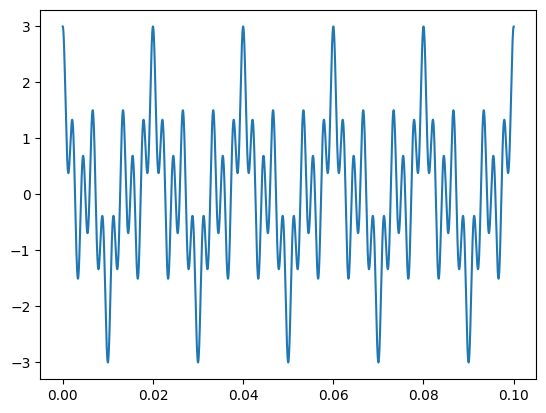

In [5]:
pt.plot(X, func)
pt.show()

## Определим спектр

(0.0, 500.0)

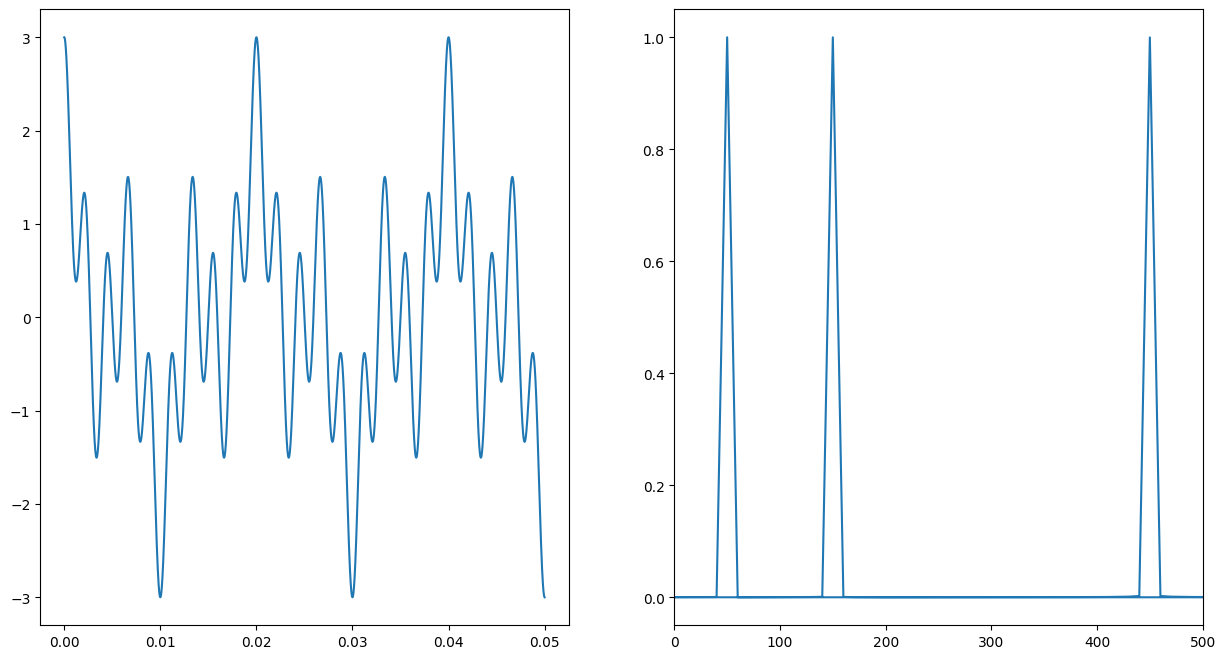

In [6]:
dt = X[1] - X[0]

fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

fig, axes = pt.subplots(1, 2, figsize=(15, 8))

axes[0].plot(X[:10000], func[:10000])
axes[1].plot(freqs, np.abs(fft_func)/N*2)
axes[1].set_xlim(0, 500)

# 2. Реализуем алгоритм фильтра Баттерворта нижних частот 2-го порядка (ФНЧ) к созданному ранее сигналу

$$H(w, w_c) = \frac{{w_c}^2}{-w^2 + j\sqrt{2}w_cw+{w_c}^2}$$

In [7]:
def bat_filter_lf(signal_four, w, w_c):
    filter = w_c**2 / (-w**2 + np.sqrt(2)*w_c*w*1j + w_c**2)
    # print(type(filter))
    # pt.plot(filter, w)
    filtered_sig = filter * signal_four
    return filtered_sig, filter



/Users/nov/Documents/NSU2026/DSP/Task0/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/nov/Documents/NSU2026/DSP/Task0/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


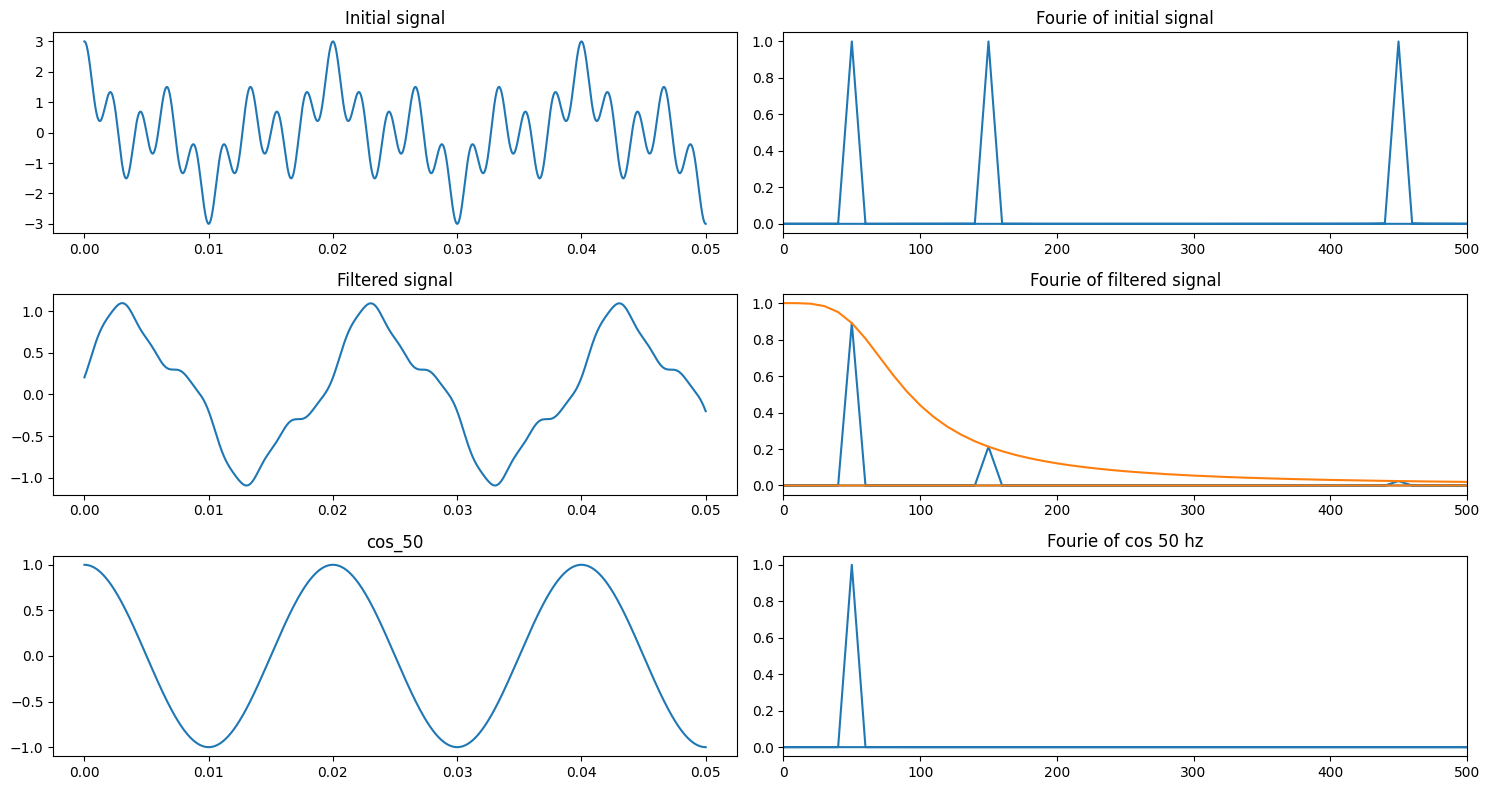

In [8]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = 70

filtered_sig_four, filter_square = bat_filter_lf(fft_func, w, w_c)

filtered_sig = np.fft.ifft(filtered_sig_four)

fig, axes = pt.subplots(3, 2, figsize=(15, 8))

axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

axes[1][0].plot(X[:10000], filtered_sig[:10000])
axes[1][0].set_title("Filtered signal")

axes[1][1].plot(freqs, np.abs(filtered_sig_four)/N*2)
axes[1][1].plot(freqs, np.abs(filter_square))
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal")

axes[2][0].plot(X[:10000], cos_50(X)[:10000])
axes[2][0].set_title("cos_50")

axes[2][1].plot(freqs, np.abs(np.fft.fft(cos_50(X)))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 50 hz")

pt.tight_layout()

# 3. Построить ФВЧ 

$$H(w, w_c) = \frac{{-w}^2}{-w^2 + j\sqrt{2}w_cw+{w_c}^2}$$

In [9]:
def bat_filter_hf(signal_four, w, w_c):
    filter = -w**2 / (-w**2 + 1j*np.sqrt(2)*w_c*w + w_c**2)
    # print(type(filter))
    # pt.plot(filter, w)
    filtered_sig = filter * signal_four
    return filtered_sig, filter



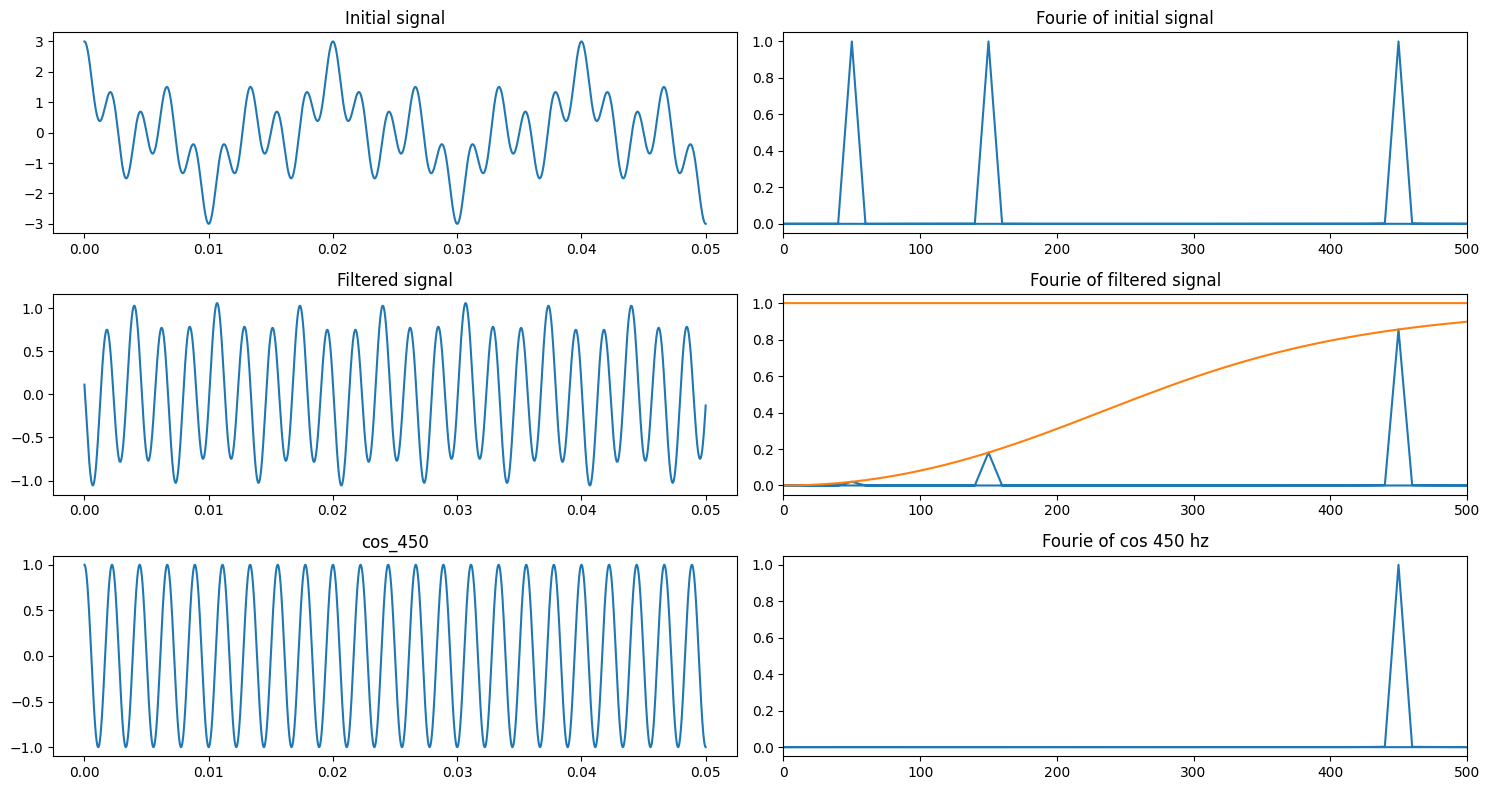

In [ ]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = 350

filtered_sig_four, filter_square = bat_filter_hf(fft_func, w, w_c)

filtered_sig = np.fft.ifft(filtered_sig_four)

fig, axes = pt.subplots(3, 2, figsize=(15, 8))

axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

axes[1][0].plot(X[:10000], filtered_sig[:10000])
axes[1][0].set_title("Filtered signal")

axes[1][1].plot(freqs, np.abs(filtered_sig_four)/N*2)
axes[1][1].plot(freqs, np.abs(filter_square))
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal")

axes[2][0].plot(X[:10000], cos_450(X)[:10000])
axes[2][0].set_title("cos_450")

axes[2][1].plot(freqs, np.abs(np.fft.fft(cos_450(X)))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 450 hz")

pt.tight_layout()

# 4. Построить ПФ, ЗФ

## Полосной фильтр

$$H_{пф}(w, w_c) = H_{фнч}(w, w_c)H_{фвч}(w, w_c)$$

In [11]:
def bat_filter_bp(signal_four, w, w_c):

    _ , H_lf = bat_filter_lf(signal_four, w, w_c[0])
    _ , H_hf = bat_filter_hf(signal_four, w, w_c[1])

    filter = H_lf * H_hf

    filtered_sig =  filter * signal_four
    return filtered_sig, filter

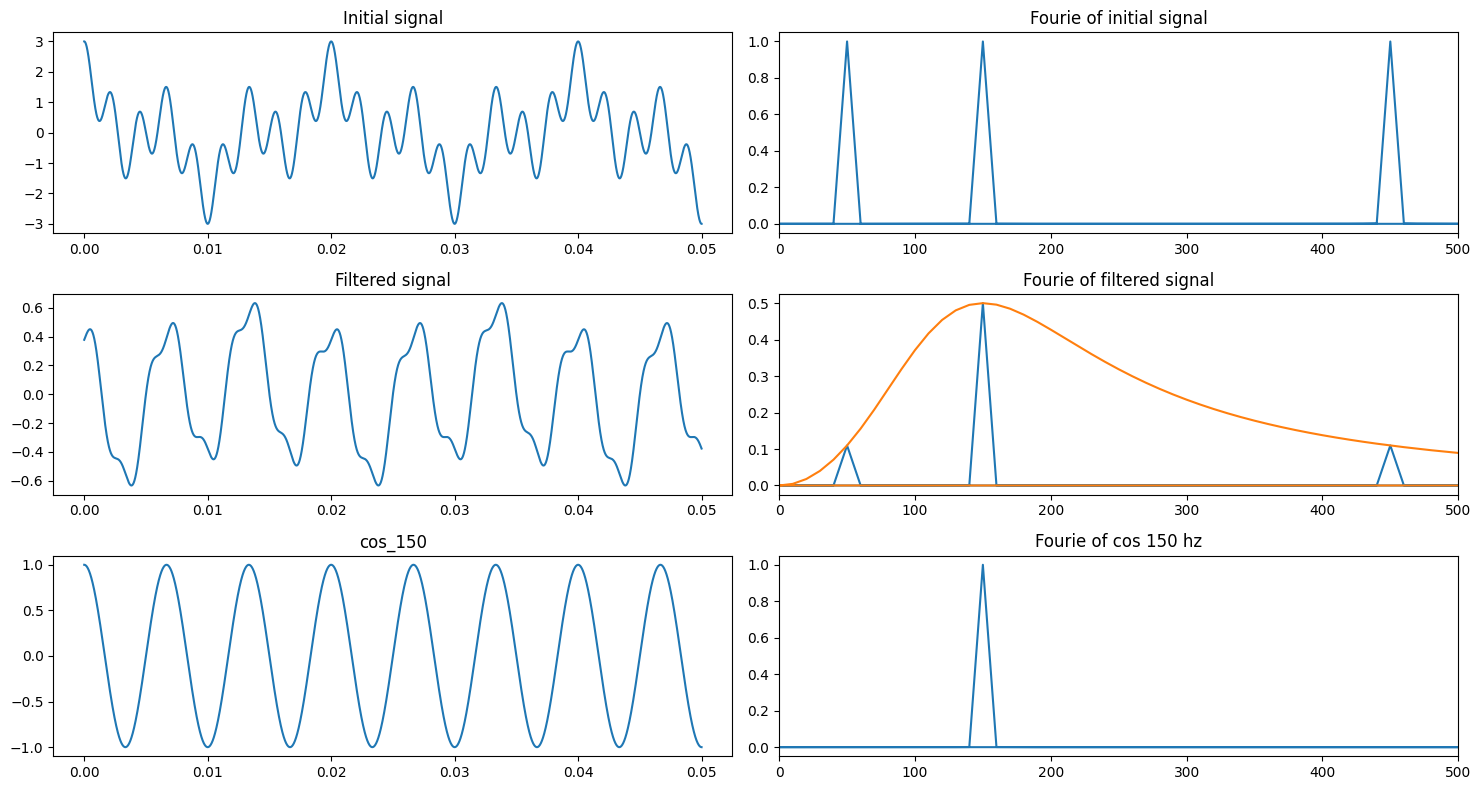

In [ ]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = (150, 150)

filtered_sig_four, filter_square = bat_filter_bp(fft_func, w, w_c)

filtered_sig = np.fft.ifft(filtered_sig_four)

fig, axes = pt.subplots(3, 2, figsize=(15, 8))

axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

axes[1][0].plot(X[:10000], filtered_sig[:10000])
axes[1][0].set_title("Filtered signal")

axes[1][1].plot(freqs, np.abs(filtered_sig_four)/N*2)
axes[1][1].plot(freqs, np.abs(filter_square))
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal")

axes[2][0].plot(X[:10000], cos_150(X)[:10000])
axes[2][0].set_title("cos_150")

axes[2][1].plot(freqs, np.abs(np.fft.fft(cos_150(X)))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 150 hz")

pt.tight_layout()

## Заграждающий фильтр

$$H_{зф}(w, w_c) = H_{фнч}(w, w_c) + H_{фвч}(w, w_c)$$

In [13]:
def bat_filter_rej(signal_four, w, w_c):

    _ , H_lf = bat_filter_lf(signal_four, w, w_c[0])
    _ , H_hf = bat_filter_hf(signal_four, w, w_c[1])

    filter = H_lf + H_hf

    filtered_sig =  filter * signal_four
    return filtered_sig, filter

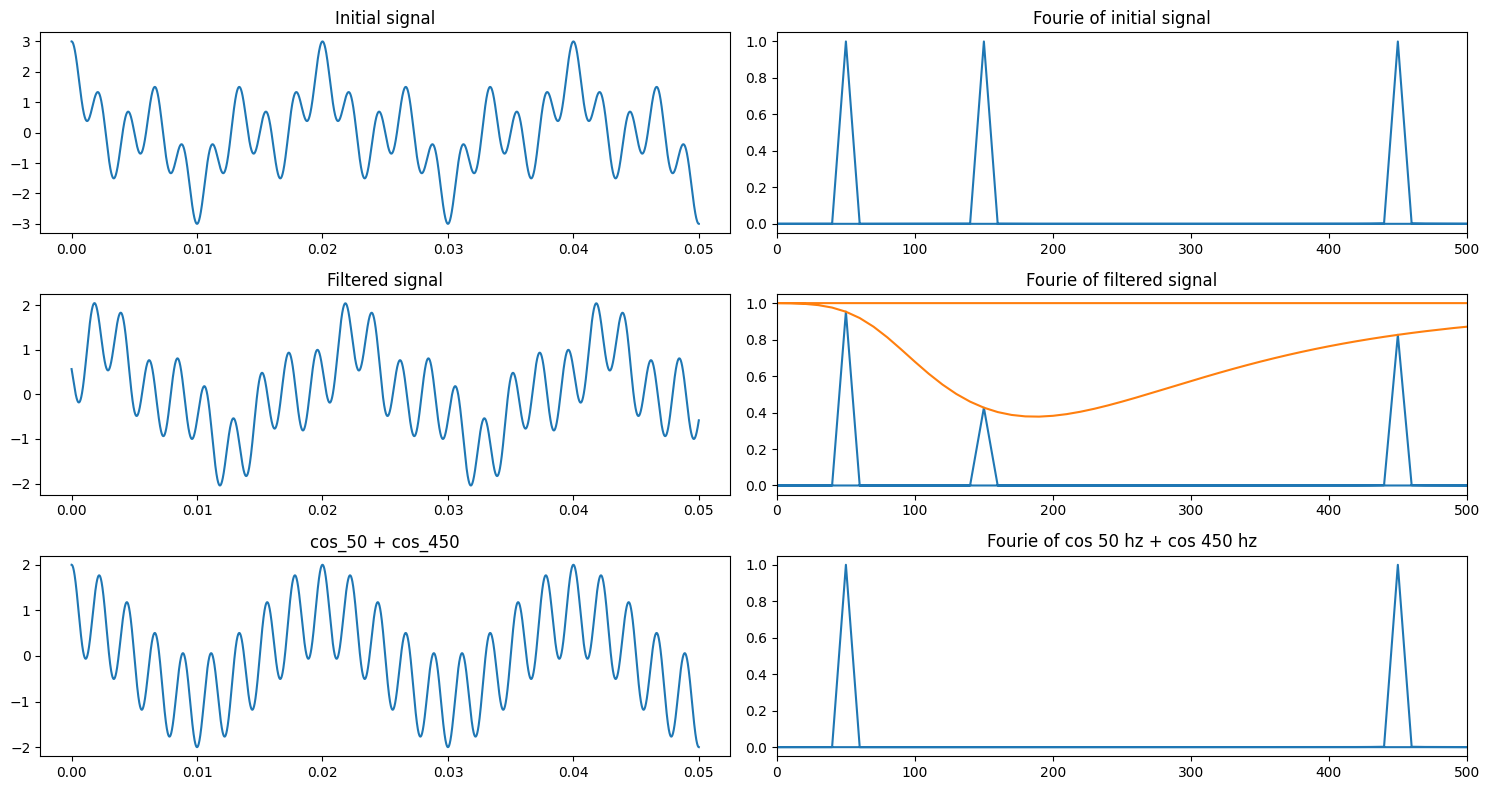

In [14]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = (100, 350)

filtered_sig_four, filter_square = bat_filter_rej(fft_func, w, w_c)

filtered_sig = np.fft.ifft(filtered_sig_four)

fig, axes = pt.subplots(3, 2, figsize=(15, 8))

axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

axes[1][0].plot(X[:10000], filtered_sig[:10000])
axes[1][0].set_title("Filtered signal")

axes[1][1].plot(freqs, np.abs(filtered_sig_four)/N*2)
axes[1][1].plot(freqs, np.abs(filter_square))
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal")

axes[2][0].plot(X[:10000], (cos_50(X) + cos_450(X))[:10000])
axes[2][0].set_title("cos_50 + cos_450")

axes[2][1].plot(freqs, np.abs(np.fft.fft((cos_50(X) + cos_450(X))))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 50 hz + cos 450 hz")

pt.tight_layout()

# 5. Построим фильтр Баттерворта 4-го и 5-го порядка

In [15]:
def butterworth(w, w_c, n):
    OMEGA = w/w_c
    A = np.sqrt(2)/w_c
    S = A + 1j*OMEGA
    filter = 1/(1 + (-1)**n * (S)**(2 * n))
    return filter

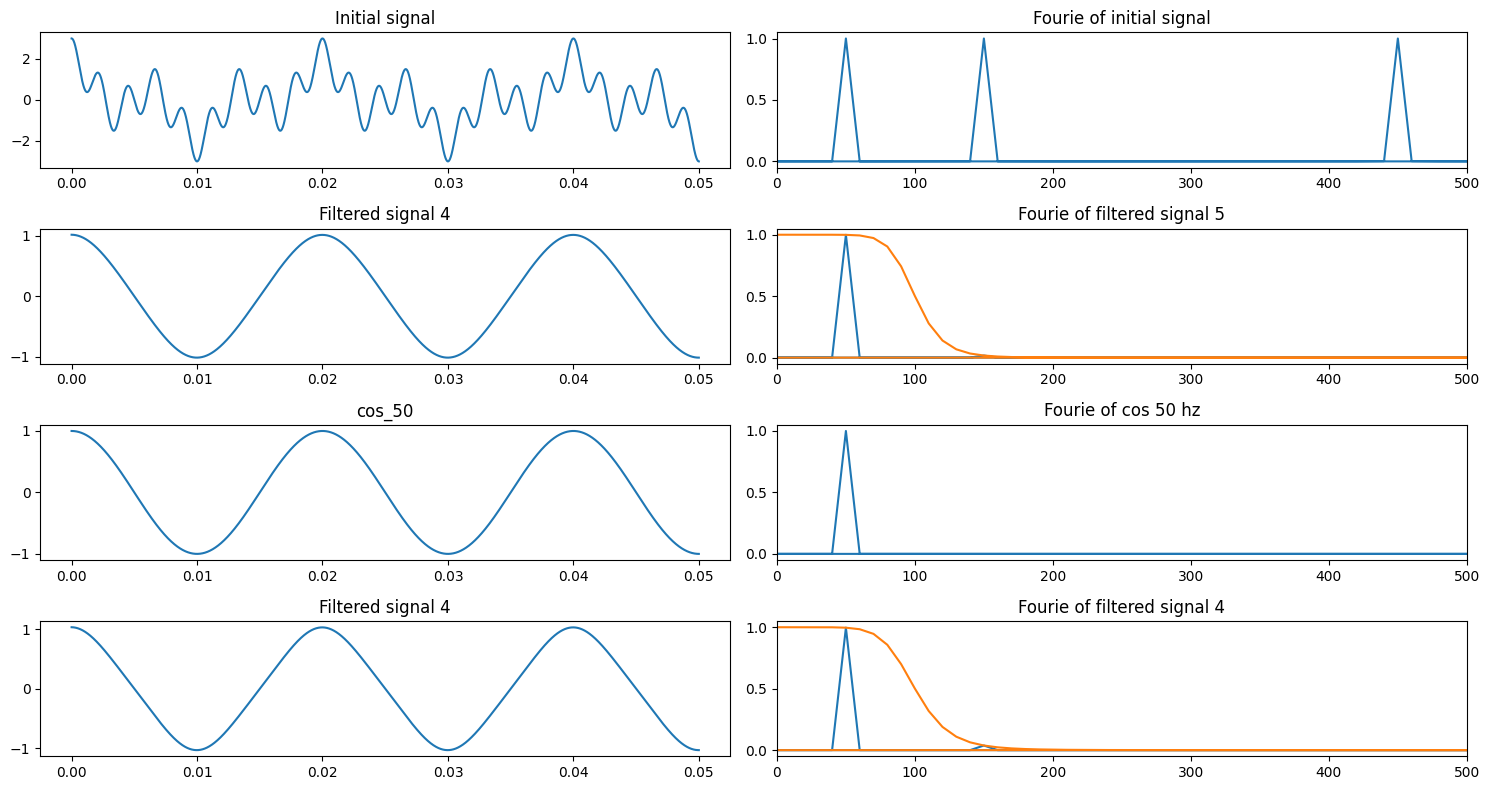

In [16]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = 100

filter_5 = butterworth(w, w_c, 5)

filtered_sig_5 = np.fft.ifft(filter_5 * fft_func)

filter_4 = butterworth(w, w_c, 4)

filtered_sig_4 = np.fft.ifft(filter_4 * fft_func)

fig, axes = pt.subplots(4, 2, figsize=(15, 8))

axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

axes[1][0].plot(X[:10000], filtered_sig_5[:10000])
axes[1][0].set_title("Filtered signal 4")

axes[1][1].plot(freqs, np.abs(filter_5 * fft_func)/N*2)
axes[1][1].plot(freqs, np.abs(filter_5))
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal 5")

axes[2][0].plot(X[:10000], (cos_50(X))[:10000])
axes[2][0].set_title("cos_50")

axes[2][1].plot(freqs, np.abs(np.fft.fft((cos_50(X))))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 50 hz")

axes[3][0].plot(X[:10000], filtered_sig_4[:10000])
axes[3][0].set_title("Filtered signal 4")

axes[3][1].plot(freqs, np.abs(filter_4 * fft_func)/N*2)
axes[3][1].plot(freqs, np.abs(filter_4))
axes[3][1].set_xlim(0, 500)
axes[3][1].set_title("Fourie of filtered signal 4")

pt.tight_layout()

## Сравним фильтры 4-го и 5-го порядка

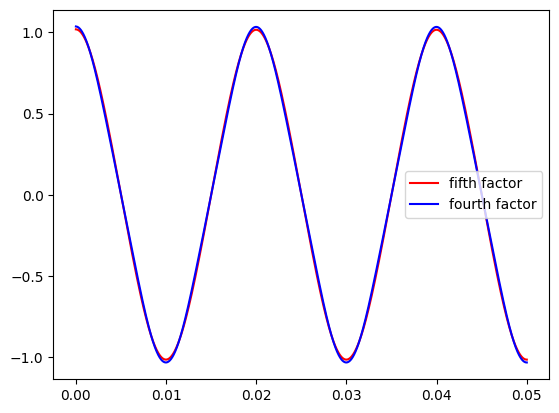

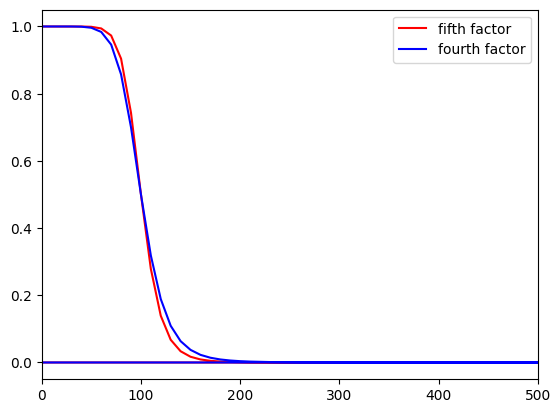

In [17]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = 100

filter_5 = butterworth(w, w_c, 5)

filtered_sig_5 = np.fft.ifft(filter_5 * fft_func)

filter_4 = butterworth(w, w_c, 4)

filtered_sig_4 = np.fft.ifft(filter_4 * fft_func)

pt.plot(X[:10000], filtered_sig_5[:10000], color='r', label='fifth factor')
pt.plot(X[:10000], filtered_sig_4[:10000], color='b', label='fourth factor')
pt.legend()
pt.show()

pt.plot(freqs, np.abs(filter_5), color='r', label='fifth factor')
pt.plot(freqs, np.abs(filter_4), color='b', label='fourth factor')
pt.xlim(0, 500)
pt.legend()
pt.show()

# 6. Сравним фильтры второго и пятого порядков

In [18]:
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)

w = freqs
w_c = 100

filter_5 = butterworth(w, w_c, 5)

filtered_sig_5 = np.fft.ifft(filter * fft_func)

filtered_sig_2_four, filter_2 = bat_filter_lf(fft_func, w, w_c)

filtered_sig_2 = np.fft.ifft(filtered_sig_2_four)

fig, axes = pt.subplots(4, 2, figsize=(15, 8))

axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

axes[1][0].plot(X[:10000], filtered_sig_5[:10000])
axes[1][0].set_title("Filtered signal 4")

axes[1][1].plot(freqs, np.abs(filter_5 * fft_func)/N*2)
axes[1][1].plot(freqs, np.abs(filter_5))
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal 5")

axes[2][0].plot(X[:10000], (cos_50(X))[:10000])
axes[2][0].set_title("cos_50")

axes[2][1].plot(freqs, np.abs(np.fft.fft((cos_50(X))))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 50 hz")

axes[3][0].plot(X[:10000], filtered_sig_2[:10000])
axes[3][0].set_title("Filtered signal 4")

axes[3][1].plot(freqs, np.abs(filter_2 * fft_func)/N*2)
axes[3][1].plot(freqs, np.abs(filter_2))
axes[3][1].set_xlim(0, 500)
axes[3][1].set_title("Fourie of filtered signal 2")

pt.tight_layout()

TypeError: unsupported operand type(s) for *: 'type' and 'complex'

# 7. Сравним мой и библиотечный фильтры Баттерворта 5-го порядка

**FROM SCIPY freqz()**


$$H(e^{jw}) = \frac{B(e^{jw})}{A(e^{jw})} = \frac{b_0 + b_1e^{-jw} + ... + b_me^{-jwM}}{a_0 + a_1e^{-jw} + ... + a_ne^{-jwN}}$$

/Users/nov/Documents/NSU2026/DSP/Task0/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/nov/Documents/NSU2026/DSP/Task0/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


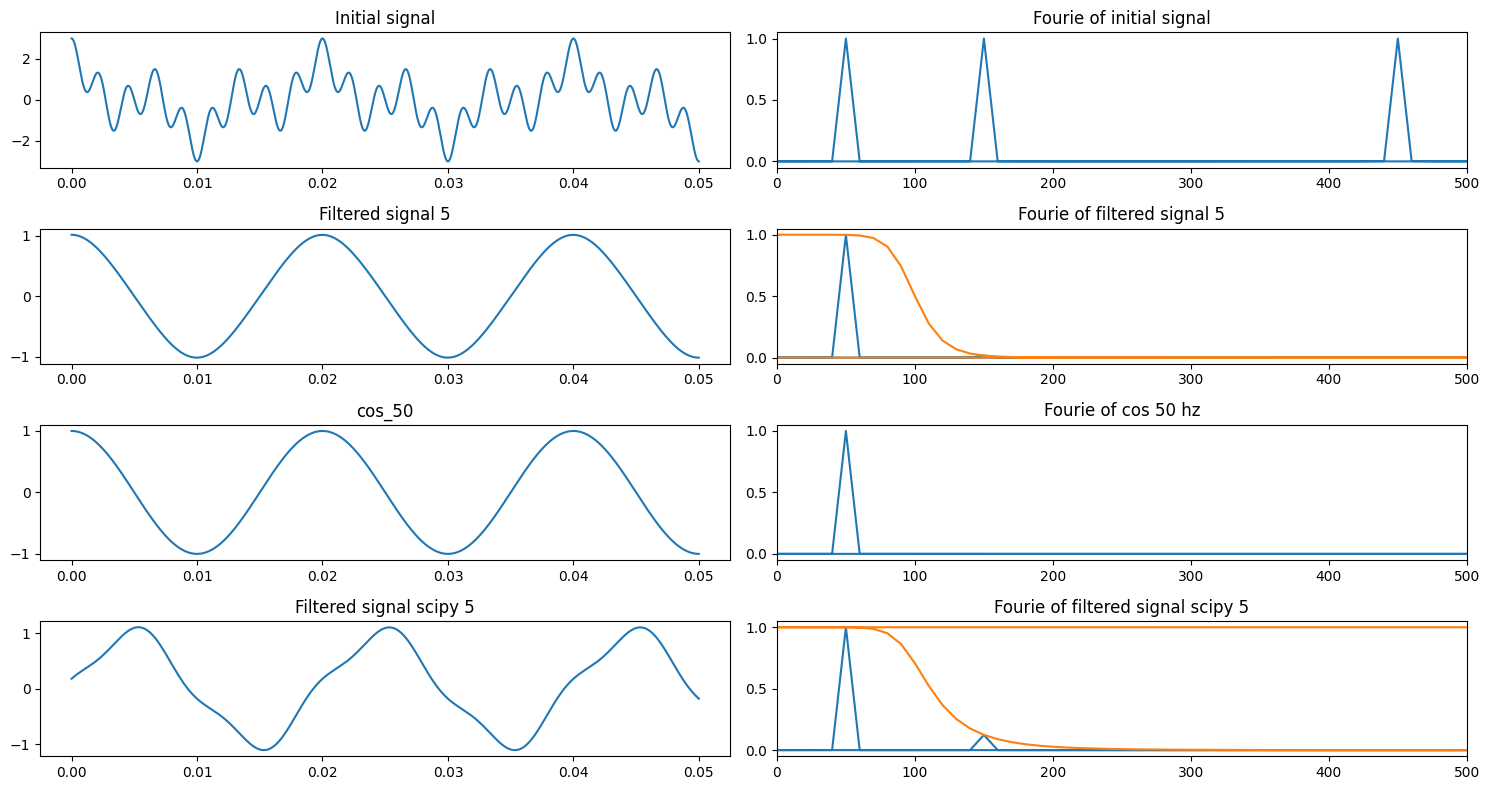

In [48]:

# Сначала сделаю преобразование Фурье функции
fft_func = np.fft.fft(func)
freqs = np.fft.fftfreq(N, dt)
#----------------------------------------------
# Зададим частоты

w = freqs
w_c = 100

#----------------------------------------------

# Отфильтруем с помощью scipy
# Проектирование цифрового ФНЧ (частота среза 100 Гц, частота дискретизации 2000 Гц)
b, a = signal.butter(5, 100, btype='low', fs=2000)

# Вычисление комплексной частотной характеристики на частотах freqs
H = np.zeros_like(freqs, dtype=complex)
pos = freqs >= 0
_, H_pos = signal.freqz(b, a, worN=freqs[pos], fs=2000)
H[pos] = H_pos
H[~pos] = np.conj(H_pos[::-1])

# Фильтрация в частотной области
filtered_spectrum = H * fft_func
filtered_signal_scipy = np.fft.ifft(filtered_spectrum)
#----------------------------------------------

# Отфильтрую своим фильтром
filter_5 = butterworth(w, w_c, 5)

filtered_sig_5 = np.fft.ifft(filter_5 * fft_func)

#----------------------------------------------


fig, axes = pt.subplots(4, 2, figsize=(15, 8))

# Отобразим обычный сигнал
axes[0][0].plot(X[:10000], func[:10000])
axes[0][0].set_title("Initial signal")

# Теперь преобразование Фурье сигнала
axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

# Отфильтрованный мною сигнал
axes[1][0].plot(X[:10000], filtered_sig_5[:10000])
axes[1][0].set_title("Filtered signal 5")

# Отобразим частоты, которые пропустил фильтр и АЧХ
axes[1][1].plot(freqs, np.abs(filter_5 * fft_func)/N*2) # Частоты
axes[1][1].plot(freqs, np.abs(filter_5)) # АЧХ
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal 5")

# Отобразим исходный сигнал, который считаем эталоном для сигнала после обработки фильтром
axes[2][0].plot(X[:10000], (cos_50(X))[:10000])
axes[2][0].set_title("cos_50")

# Посмотрим на Преобразование Фурье косинуса
axes[2][1].plot(freqs, np.abs(np.fft.fft((cos_50(X))))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 50 hz")

# Отобразим отфильтрованный с помощью scipy сигнал
axes[3][0].plot(X[:10000], filtered_signal_scipy[:10000])
axes[3][0].set_title("Filtered signal scipy 5")

# Отобразим АЧХ и Частоты фильтра scipy
axes[3][1].plot(freqs, np.abs(filtered_spectrum)/N*2)
axes[3][1].plot(freqs, np.abs(np.abs(H)))
axes[3][1].set_xlim(0, 500)
axes[3][1].set_title("Fourie of filtered signal scipy 5")

pt.tight_layout()

# 8. Добавим шум и посмотрим как поменяется вся система

In [56]:
def noise(x):
    return x + np.random.normal(0, 0.2, x.shape)

In [57]:
noisy_func = noise(func)

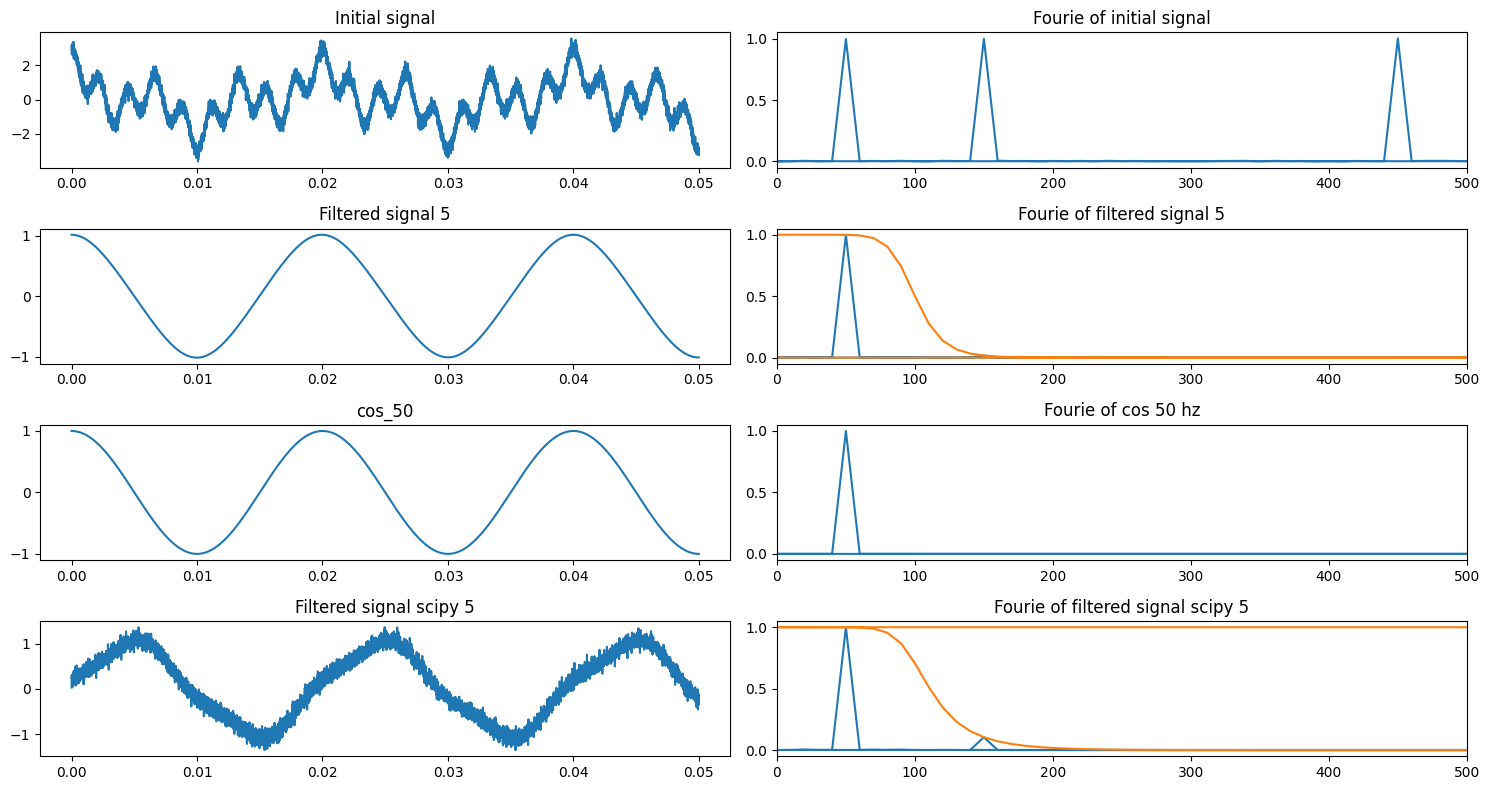

In [59]:

# Сначала сделаю преобразование Фурье функции
fft_func = np.fft.fft(noisy_func)
freqs = np.fft.fftfreq(N, dt)
#----------------------------------------------
# Зададим частоты

w = freqs
w_c = 100

#----------------------------------------------

# Отфильтруем с помощью scipy
# Проектирование цифрового ФНЧ (частота среза 100 Гц, частота дискретизации 2000 Гц)
b, a = signal.butter(5, 100, btype='low', fs=1000)

# Вычисление комплексной частотной характеристики на частотах freqs
H = np.zeros_like(freqs, dtype=complex)
pos = freqs >= 0
_, H_pos = signal.freqz(b, a, worN=freqs[pos], fs=1000)
H[pos] = H_pos
H[~pos] = np.conj(H_pos[::-1])

# Фильтрация в частотной области
filtered_spectrum = H * fft_func
filtered_signal_scipy = np.fft.ifft(filtered_spectrum)
#----------------------------------------------

# Отфильтрую своим фильтром
filter_5 = butterworth(w, w_c, 5)

filtered_sig_5 = np.fft.ifft(filter_5 * fft_func)

#----------------------------------------------


fig, axes = pt.subplots(4, 2, figsize=(15, 8))

# Отобразим обычный сигнал
axes[0][0].plot(X[:10000], noisy_func[:10000])
axes[0][0].set_title("Initial signal")

# Теперь преобразование Фурье сигнала
axes[0][1].plot(freqs, np.abs(fft_func)/N*2)
axes[0][1].set_xlim(0, 500)
axes[0][1].set_title("Fourie of initial signal")

# Отфильтрованный мною сигнал
axes[1][0].plot(X[:10000], filtered_sig_5[:10000])
axes[1][0].set_title("Filtered signal 5")

# Отобразим частоты, которые пропустил фильтр и АЧХ
axes[1][1].plot(freqs, np.abs(filter_5 * fft_func)/N*2) # Частоты
axes[1][1].plot(freqs, np.abs(filter_5)) # АЧХ
axes[1][1].set_xlim(0, 500)
axes[1][1].set_title("Fourie of filtered signal 5")

# Отобразим исходный сигнал, который считаем эталоном для сигнала после обработки фильтром
axes[2][0].plot(X[:10000], (cos_50(X))[:10000])
axes[2][0].set_title("cos_50")

# Посмотрим на Преобразование Фурье косинуса
axes[2][1].plot(freqs, np.abs(np.fft.fft((cos_50(X))))/N*2)
axes[2][1].set_xlim(0, 500)
axes[2][1].set_title("Fourie of cos 50 hz")

# Отобразим отфильтрованный с помощью scipy сигнал
axes[3][0].plot(X[:10000], filtered_signal_scipy[:10000])
axes[3][0].set_title("Filtered signal scipy 5")

# Отобразим АЧХ и Частоты фильтра scipy
axes[3][1].plot(freqs, np.abs(filtered_spectrum)/N*2)
axes[3][1].plot(freqs, np.abs(np.abs(H)))
axes[3][1].set_xlim(0, 500)
axes[3][1].set_title("Fourie of filtered signal scipy 5")

pt.tight_layout()

У меня получился фильтр, лучше подавляющий шумы. К тому же он реще, чем Butterworth из signal

# 9. Реализуем ФНЧ Чебышева 1-го рода N порядка